In [4]:
%pip install opencv-python tqdm

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 1.2 MB/s eta 0:00:34
    --------------------------------------- 0.8/40.2 MB 991.8 kB/s eta 0:00:40
    --------------------------------------- 0.8/40.2 MB 991.8 kB/s eta 0:00:40
    --------------------------------------- 0.8/40.2 MB 991.8 kB/s eta 0:00:40
    --------------------------------------- 0.8/40.2 MB 991.8 kB/s eta 0:00:40
   - -------------------------------------- 1.0/40.2 MB 580.3 kB/s eta 0:01:08
   - -------------------------------------- 1.0/40.2 MB 580.3 kB/s eta 0:01:08
   - -------------------------------------- 1.0/40.2 MB 580.3 kB/s eta 0:01:08
   - -------------------------------------- 1.3/40.2 MB 539.3 kB/s eta 0:01:13
 

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# --- CONFIGURACIÓN DE RUTAS ---
PROJECT_ROOT = Path("..") 
INPUT_DIR = PROJECT_ROOT / "src" / "data" / "processed" / "imagenes_RGB"
OUTPUT_DIR = PROJECT_ROOT / "src" / "data" / "processed" / "imagenes_ARP"

# Configuración de la imagen
TARGET_SIZE = (224, 224)

# Crear directorio de salida si no existe
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"📂 Leyendo desde: {INPUT_DIR.resolve()}")
print(f"📂 Guardando en: {OUTPUT_DIR.resolve()}")

📂 Leyendo desde: C:\TFG\src\data\processed\imagenes_RGB
📂 Guardando en: C:\TFG\src\data\processed\imagenes_ARP


## **Celda 2: Función de Transformación ARP (Polar)**

In [9]:
def convert_to_arp(image_path, target_size=(224, 224)):
    """
    Convierte una imagen dermatoscópica a su representación ARP (Polar).
    1. Carga en color.
    2. Convierte a Escala de Grises (Mejor para detectar bordes/estructura).
    3. Aplica cv2.linearPolar (Transformación cartesiana a polar).
    4. Redimensiona al tamaño objetivo.
    """
    # Leer imagen
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    
    # 1. Convertir a Escala de Grises
    # ARP se centra en la geometría y textura, el color RGB ya lo tiene la otra rama.
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 2. Calcular centro y radio máximo
    h, w = gray.shape
    center = (w / 2, h / 2)
    # Calculamos el radio hasta la esquina para no perder información
    max_radius = np.sqrt((w/2)**2 + (h/2)**2)
    
    # 3. Transformación Polar (Linear Polar)
    # El eje X se convierte en el Radio, el eje Y en el Ángulo (o viceversa según implementación)
    # cv2.WARP_FILL_OUTLIERS rellena lo que sobra.
    arp_image = cv2.linearPolar(gray, center, max_radius, cv2.WARP_FILL_OUTLIERS)
    
    # 4. Rotación (Opcional, estética)
    # A veces se rota 90 grados para que el radio quede en el eje vertical.
    # Para la CNN es indiferente, lo dejaremos tal cual sale de OpenCV.
    
    # 5. Resize final
    arp_image_resized = cv2.resize(arp_image, target_size)
    
    return arp_image_resized

## **Celda 3: Visualización (Prueba antes de ejecutar todo)**

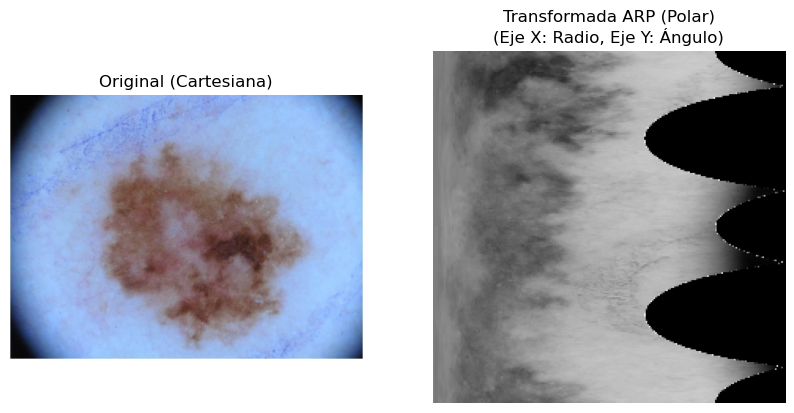

In [10]:
# Buscar una imagen de prueba (la primera que encuentre)
sample_images = list(INPUT_DIR.glob("*.jpg"))

if sample_images:
    sample_path = sample_images[0]
    
    # Generar ARP
    arp_img = convert_to_arp(sample_path)
    
    # Cargar original para comparar
    orig_img = cv2.imread(str(sample_path))
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    
    # Plot
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.title("Original (Cartesiana)")
    plt.imshow(orig_img)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Transformada ARP (Polar)\n(Eje X: Radio, Eje Y: Ángulo)")
    plt.imshow(arp_img, cmap='gray')
    plt.axis('off')
    
    plt.show()
else:
    print("❌ No se encontraron imágenes .jpg en el directorio de entrada.")

## **Celda 4: Procesamiento Masivo**

In [11]:
# Lista de todas las imágenes (puedes añadir .png si tienes)
image_files = list(INPUT_DIR.glob("*.jpg"))
print(f"🚀 Iniciando conversión de {len(image_files)} imágenes...")

error_count = 0

# Usamos tqdm para barra de progreso
for img_path in tqdm(image_files):
    try:
        # 1. Convertir
        arp_result = convert_to_arp(img_path, TARGET_SIZE)
        
        if arp_result is not None:
            # 2. Guardar
            # Mantenemos EL MISMO NOMBRE de archivo para que los CSVs funcionen igual
            save_path = OUTPUT_DIR / img_path.name
            
            # cv2.imwrite guarda en BGR, pero como es escala de grises (1 canal), da igual.
            cv2.imwrite(str(save_path), arp_result)
        else:
            error_count += 1
            
    except Exception as e:
        print(f"Error procesando {img_path.name}: {e}")
        error_count += 1

print("\n" + "="*50)
print(f"✅ Proceso finalizado.")
print(f"📁 Imágenes guardadas en: {OUTPUT_DIR}")
print(f"❌ Errores: {error_count}")
print("="*50)

🚀 Iniciando conversión de 427711 imágenes...


100%|██████████| 427711/427711 [1:15:54<00:00, 93.91it/s] 


✅ Proceso finalizado.
📁 Imágenes guardadas en: ..\src\data\processed\imagenes_ARP
❌ Errores: 0
